# XGBoost (Extreme Gradient Boosting): Comprehensive Guide

## 1. What is XGBoost?
**XGBoost** (Extreme Gradient Boosting) is an optimized, highly efficient implementation of **Gradient Boosted Decision Trees (GBDT)**. It is designed to push the limits of computational speed and model performance, making it one of the dominant algorithms in machine learning, particularly for structured or tabular data and Kaggle competitions.

---

## 2. Why is it Used?
Standard gradient boosting builds trees sequentially to minimize errors, but it often suffers from slow training speeds and overfitting on complex, noisy data. XGBoost was engineered to solve these bottlenecks by combining advanced system-level optimizations with rigorous mathematical regularization. 

It is the go-to choice when you need:
* **High Predictive Accuracy:** Outperforms many traditional algorithms on tabular datasets.
* **Speed & Scalability:** Utilizes parallel processing and memory optimization to handle massive datasets quickly.
* **Robustness:** Handles missing data and prevents overfitting out of the box.

---

## 3. Key Advantages (Pros)

### A. Regularization (L1 & L2)
* **What it does:** Adds penalty terms ($L1$ Lasso and $L2$ Ridge) to the objective/loss function.
* **Why it matters:** Controls model complexity and performs pre-pruning. If a split doesn't significantly improve model performance, regularization stops it from forming, preventing overfitting.

### B. Sparsity-Aware Split Finding (Missing Value Handling)
* **What it does:** Automatically handles missing values (`NaN` or blanks) in the dataset during training.
* **Why it matters:** Eliminates the need for manual imputation (like mean/median filling). The algorithm automatically learns a **default direction** (left or right branch) for missing values at every node to minimize loss.

### C. Column Block Structure & Parallelization
* **What it does:** Organizes data into sorted memory blocks (columns) before training begins.
* **Why it matters:** Although boosting is sequential (Tree #2 depends on Tree #1), finding the best split *within* a tree is parallelized. XGBoost utilizes all available CPU cores simultaneously to scan these sorted blocks, drastically reducing execution time.

### D. Second-Order Optimization (Taylor Expansion & Hessian)
* **What it does:** Uses both the **First Derivative (Gradient)** and **Second Derivative (Hessian)** of the loss function via Taylor Series Expansion.
* **Why it matters:** While standard GBM only looks at the slope (direction), XGBoost looks at the curvature (how fast the slope is changing). This allows the optimizer to take precise, optimal steps, leading to faster convergence and higher accuracy.

---

## 4. Disadvantages & Limitations (Cons)

### A. Hyperparameter Sensitivity
* XGBoost has numerous hyperparameters (e.g., `learning_rate`, `max_depth`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`). Finding the optimal combination requires extensive tuning using techniques like Grid Search or Optuna.

### B. Prone to Overfitting on Small Datasets
* If the dataset is very small, powerful boosting algorithms can easily memorize the noise rather than learning general patterns, even with regularization.

### C. Computationally Expensive for Massive Scale Without Proper Setup
* While highly optimized, training on millions of rows with deep trees without GPU acceleration or proper sub-sampling can consume substantial memory and time.

### D. Black-Box Nature
* Like most ensemble tree models, XGBoost is less interpretable than a single linear regression or shallow decision tree, requiring tools like SHAP values to explain feature contributions.

---

## 5. Summary: When to Use XGBoost?
* **Best For:** Structured/tabular data, classification and regression problems, high-performance predictive modeling, and tabular competition tasks.
* **Avoid For:** Unstructured data (images, raw audio, text—where Neural Networks/Deep Learning excel) or extremely small datasets where simpler linear models suffice.

In [1]:
%pip install xgboost -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier



In [2]:
df = pd.read_csv("C:/Users/hp/Desktop/Machine_Learning/data.csv")
print("Success! Data loaded.")
df.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_18164\1530099147.py:1: DtypeWarning: Columns (0: coupon_code, 1: additional) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:/Users/hp/Desktop/Machine_Learning/data.csv")


Success! Data loaded.


,id,old_order_id,increment_id,status,channel_name,is_guest,customer_email,customer_first_name,customer_last_name,shipping_method,...,additional,tabby_payment_id,tabby_order_status,paymob_intention_id,paymob_cents_amount,tamara_order_id,tamara_checkout_id,cko_hpp_id,cko_payment_id,cko_session_id
0,1,NaN,ORD-00000001,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,NaN,ORD-00000002,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NaN,ORD-00000003,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,ORD-00000004,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,ORD-00000005,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:

df_clean = df.copy()

print(f"Initial Dataset Shape: {df_clean.shape}")
df_clean = df_clean.drop_duplicates()
df_clean['target'] = df_clean['status'].apply(lambda x: 0 if str(x).strip().lower() == 'completed' else 1)
df_clean = df_clean.dropna(subset=['target'])



Initial Dataset Shape: (146201, 85)


### ==========================================
### FEATURE ENGINEERING (The Core Magic)
### ==========================================

In [4]:

df_clean['discount_ratio'] = df_clean['discount_amount'] / (df_clean['sub_total'] + 1e-5)
df_clean['tax_ratio'] = df_clean['tax_amount'] / (df_clean['sub_total'] + 1e-5)
df_clean['shipping_ratio'] = df_clean['shipping_amount'] / (df_clean['grand_total'] + 1e-5)
df_clean['avg_item_price'] = df_clean['sub_total'] / (df_clean['total_qty_ordered'] + 1e-5)
df_clean['net_basket_value'] = df_clean['sub_total'] - df_clean['discount_amount']



### ==========================================
### FEATURE SELECTION & HIGH CARDINALITY DROP
### ==========================================

In [5]:

useless_cols = [
    'cashback', 'tabby_payment_id', 'tabby_order_status', 'paymob_intention_id', 
    'paymob_cents_amount', 'tamara_order_id', 'tamara_checkout_id', 'cko_hpp_id', 
    'cko_payment_id', 'cko_session_id', 'id', 'old_order_id', 'increment_id', 
    'customer_email', 'customer_first_name', 'customer_last_name', 'shipping_title', 
    'shipping_description', 'coupon_code', 'created_at', 'updated_at', 'additional', 'status'
]
df_clean = df_clean.drop(columns=[col for col in useless_cols if col in df_clean.columns])
X_raw = df_clean.drop(columns=['target'])
y = df_clean['target']



### ==========================================
### HANDLING MISSING VALUES & ENCODING
### ==========================================

In [6]:

num_cols = X_raw.select_dtypes(include=['number']).columns
X_raw[num_cols] = X_raw[num_cols].fillna(X_raw[num_cols].median())
cat_cols = X_raw.select_dtypes(include=['object', 'string', 'category']).columns
high_card_cols = [col for col in cat_cols if X_raw[col].nunique() > 50]
if high_card_cols:
    X_raw = X_raw.drop(columns=high_card_cols)
    cat_cols = X_raw.select_dtypes(include=['object', 'string', 'category']).columns

X_raw[cat_cols] = X_raw[cat_cols].fillna('Missing')

X = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)
print(f"Final Processed Data Shape for Training: {X.shape}")



Final Processed Data Shape for Training: (146201, 75)


### ==========================================
### TRAIN-TEST SPLIT (Stratified)
### ==========================================

In [7]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



### ==========================================
### MODEL TRAINING & EVALUATION FUNCTION
### ==========================================


=============== Training Decision Tree ===============
Decision Tree Accuracy: 0.9404

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91      9245
           1       0.96      0.96      0.96     19996

    accuracy                           0.94     29241
   macro avg       0.93      0.93      0.93     29241
weighted avg       0.94      0.94      0.94     29241



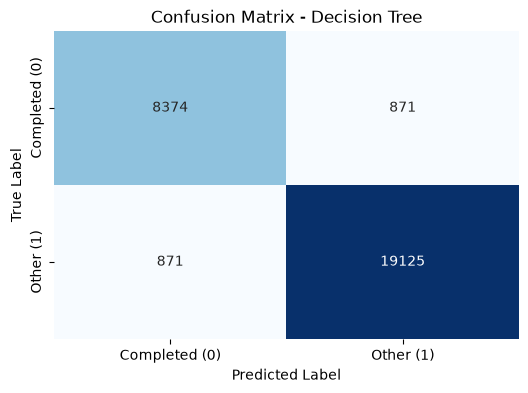


=============== Training Random Forest ===============
Random Forest Accuracy: 0.9487

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92      9245
           1       0.96      0.96      0.96     19996

    accuracy                           0.95     29241
   macro avg       0.94      0.94      0.94     29241
weighted avg       0.95      0.95      0.95     29241



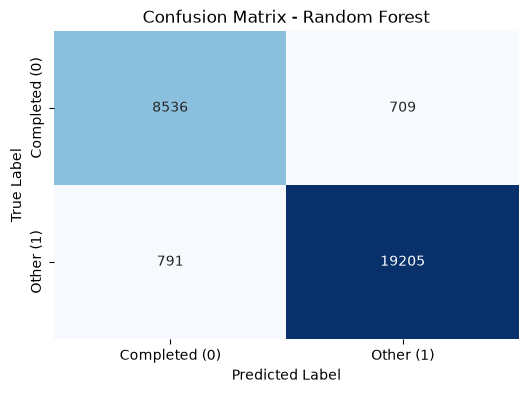


=============== Training XGBoost ===============
XGBoost Accuracy: 0.9582

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.96      0.94      9245
           1       0.98      0.96      0.97     19996

    accuracy                           0.96     29241
   macro avg       0.95      0.96      0.95     29241
weighted avg       0.96      0.96      0.96     29241



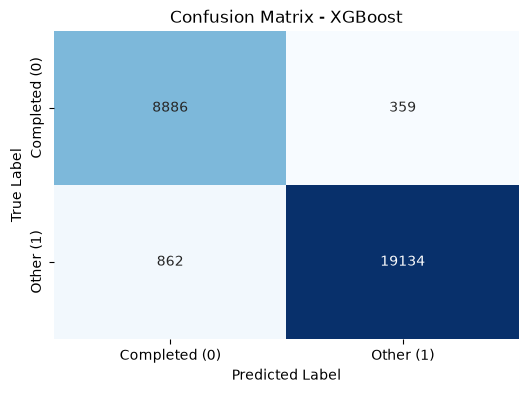

In [9]:

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
}

trained_models = {}
for name, model in models.items():
    print(f"\n{'='*15} Training {name} {'='*15}")
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Completed (0)', 'Other (1)'],
                yticklabels=['Completed (0)', 'Other (1)'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

### Testing

In [10]:

print(f"{'='*10} OVERFITTING CHECK (XGBoost) {'='*10}")
train_pred = trained_models["XGBoost"].predict(X_train)
test_pred = trained_models["XGBoost"].predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"Training Accuracy: {train_acc:.4f} (99% ya uske kareeb ho toh overfit ho sakta hai)")
print(f"Testing Accuracy:  {test_acc:.4f}")


print(f"\n{'='*10} K-FOLD CROSS VALIDATION (5-Folds) {'='*10}")
# 5 alag-alag validation folds par XGBoost ko test karna
cv_scores = cross_val_score(models["XGBoost"], X, y, cv=5, scoring='accuracy', n_jobs=-1)

print(f"Cross-Validation Scores for each fold: {np.round(cv_scores, 4)}")
print(f"Average CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# ==========================================
# 3. LIVE INFERENCE TEST (New Order Prediction)
# ==========================================
print(f"\n{'='*10} LIVE INFERENCE TEST {'='*10}")
# X_test ka pehla row utha kar dekhte hain ke model kya predict karta hai
sample_order = X_test.iloc[[0]]
actual_label = y_test.iloc[0]

predicted_class = trained_models["XGBoost"].predict(sample_order)[0]
predicted_prob = trained_models["XGBoost"].predict_proba(sample_order)[0]

label_name = "Completed (0)" if predicted_class == 0 else "Other (1)"
actual_name = "Completed (0)" if actual_label == 0 else "Other (1)"

print(f"Sample Order Prediction: {label_name}")
print(f"Model Confidence Probabilities: [Completed: {predicted_prob[0]:.4f}, Other: {predicted_prob[1]:.4f}]")
print(f"Asal (True) Label kya tha: {actual_name}")

========== OVERFITTING CHECK (XGBoost) ==========
Training Accuracy: 0.9603 (99% ya uske kareeb ho toh overfit ho sakta hai)
Testing Accuracy:  0.9582

========== K-FOLD CROSS VALIDATION (5-Folds) ==========


NameError: name 'cross_val_score' is not defined